In [1]:
import numpy as np

# 두 벡터의 유사도 반환하는 함수
def cos_similarity(v1, v2):
    dot_product = np.dot(v1, v2)
    l2_norm = (np.sqrt(sum(np.square(v1))) * np.sqrt(sum(np.square(v2))))
    similarity = dot_product / l2_norm    
   
    return similarity

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer


# 문장 3개 => 벡터 3개
doc_list = ['if you take the blue pill, the story ends' ,
            'if you take the red pill, you stay in Wonderland',
            'if you take the red pill, I show you how deep the rabbit hole goes']


tfidf_vect_simple = TfidfVectorizer()
feature_vect_simple = tfidf_vect_simple.fit_transform(doc_list)
print(feature_vect_simple.shape)


(3, 18)


In [3]:
tfidf_vect_simple.vocabulary_   # 단어 사전 확인

{'if': 6,
 'you': 17,
 'take': 14,
 'the': 15,
 'blue': 0,
 'pill': 8,
 'story': 13,
 'ends': 2,
 'red': 10,
 'stay': 12,
 'in': 7,
 'wonderland': 16,
 'show': 11,
 'how': 5,
 'deep': 1,
 'rabbit': 9,
 'hole': 4,
 'goes': 3}

In [4]:
tfidf_vect_simple.get_feature_names_out()   # 단어만 볼 수 있음.

array(['blue', 'deep', 'ends', 'goes', 'hole', 'how', 'if', 'in', 'pill',
       'rabbit', 'red', 'show', 'stay', 'story', 'take', 'the',
       'wonderland', 'you'], dtype=object)

In [5]:
feature_vect_simple[0]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8 stored elements and shape (1, 18)>

In [6]:
feature_vect_dense = feature_vect_simple.todense()
feature_vect_dense[0]

matrix([[0.4155636 , 0.        , 0.4155636 , 0.        , 0.        ,
         0.        , 0.24543856, 0.        , 0.24543856, 0.        ,
         0.        , 0.        , 0.        , 0.4155636 , 0.24543856,
         0.49087711, 0.        , 0.24543856]])

In [7]:
feature_vect_dense[2]

matrix([[0.        , 0.30985601, 0.        , 0.30985601, 0.30985601,
         0.30985601, 0.18300595, 0.        , 0.18300595, 0.30985601,
         0.23565348, 0.30985601, 0.        , 0.        , 0.18300595,
         0.3660119 , 0.        , 0.3660119 ]])

In [ ]:
# TFidfVectorizer로 transform()한 결과는 Sparse Matrix이므로 Dense Matrix로 변환.
feature_vect_dense = feature_vect_simple.todense()


#첫번째 문장과 두번째 문장의 feature vector  추출
vect1 = np.array(feature_vect_dense[0]).reshape(-1,)
vect2 = np.array(feature_vect_dense[1]).reshape(-1,)


#첫번째 문장과 두번째 문장의 feature vector로 두개 문장의 Cosine 유사도 추출
similarity_simple = cos_similarity(vect1, vect2 )
print('문장 1, 문장 2 Cosine 유사도: {0:.3f}'.format(similarity_simple))


문장 1, 문장 2 Cosine 유사도: 0.402


In [11]:
print(feature_vect_dense)
print("-----")
print(feature_vect_simple)
print(type(feature_vect_dense))
print(type(feature_vect_simple))


[[0.4155636  0.         0.4155636  0.         0.         0.
  0.24543856 0.         0.24543856 0.         0.         0.
  0.         0.4155636  0.24543856 0.49087711 0.         0.24543856]
 [0.         0.         0.         0.         0.         0.
  0.23402865 0.39624495 0.23402865 0.         0.3013545  0.
  0.39624495 0.         0.23402865 0.23402865 0.39624495 0.4680573 ]
 [0.         0.30985601 0.         0.30985601 0.30985601 0.30985601
  0.18300595 0.         0.18300595 0.30985601 0.23565348 0.30985601
  0.         0.         0.18300595 0.3660119  0.         0.3660119 ]]
-----
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 29 stored elements and shape (3, 18)>
  Coords	Values
  (0, 6)	0.24543855687841593
  (0, 17)	0.24543855687841593
  (0, 14)	0.24543855687841593
  (0, 15)	0.49087711375683185
  (0, 0)	0.41556360057939173
  (0, 8)	0.24543855687841593
  (0, 13)	0.41556360057939173
  (0, 2)	0.41556360057939173
  (1, 6)	0.2340286519091622
  (1, 17)	0.4680573038183244
 

In [10]:
vect1 = np.array(feature_vect_dense[0]).reshape(-1,)
vect3 = np.array(feature_vect_dense[2]).reshape(-1,)
similarity_simple = cos_similarity(vect1, vect3 )
print('문장 1, 문장 3 Cosine 유사도: {0:.3f}'.format(similarity_simple))


vect2 = np.array(feature_vect_dense[1]).reshape(-1,)
vect3 = np.array(feature_vect_dense[2]).reshape(-1,)
similarity_simple = cos_similarity(vect2, vect3 )
print('문장 2, 문장 3 Cosine 유사도: {0:.3f}'.format(similarity_simple))


문장 1, 문장 3 Cosine 유사도: 0.404
문장 2, 문장 3 Cosine 유사도: 0.456


In [11]:
from sklearn.metrics.pairwise import cosine_similarity


similarity_simple_pair = cosine_similarity(feature_vect_simple[0] , feature_vect_simple)    # 첫 번째 문장 기준으로 비교.
print(similarity_simple_pair)


[[1.         0.40207758 0.40425045]]


In [12]:
similarity_simple_pair = cosine_similarity(feature_vect_simple , feature_vect_simple)   # 전체 비교
print(similarity_simple_pair)
print('shape:',similarity_simple_pair.shape)


[[1.         0.40207758 0.40425045]
 [0.40207758 1.         0.45647296]
 [0.40425045 0.45647296 1.        ]]
shape: (3, 3)


In [13]:
# Opinion Review 문서 유사도 측정: 51개 파일의 유사도 측정
from nltk.stem import WordNetLemmatizer
import nltk
import string


remove_punct_dict = dict((ord(punct), None) for punct in string.punctuation)
lemmar = WordNetLemmatizer()


# 입력으로 들어온 token단어들에 대해서 lemmatization 어근 변환.
def LemTokens(tokens):
    return [lemmar.lemmatize(token) for token in tokens]


# TfidfVectorizer 객체 생성 시 tokenizer인자로 해당 함수를 설정하여 lemmatization 적용
# 입력으로 문장을 받아서 stop words 제거-> 소문자 변환 -> 단어 토큰화 -> lemmatization 어근 변환.
def LemNormalize(text):
    return LemTokens(nltk.word_tokenize(text.lower().translate(remove_punct_dict)))

In [15]:
import pandas as pd
import glob, os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')


path = r'..\data\topics'
all_files = glob.glob(os.path.join(path, "*.data"))    
filename_list = []
opinion_text = []


for file_ in all_files:
    df = pd.read_table(file_,index_col=None, header=0,encoding='latin1')
    filename_ = file_.split('\\')[-1]
    filename = filename_.split('.')[0]
    filename_list.append(filename)
    opinion_text.append(df.to_string())


document_df = pd.DataFrame({'filename':filename_list, 'opinion_text':opinion_text})

tfidf_vect = TfidfVectorizer(tokenizer=LemNormalize, stop_words='english' , ngram_range=(1,2), min_df=0.05, max_df=0.85 )
feature_vect = tfidf_vect.fit_transform(document_df['opinion_text'])


km_cluster = KMeans(n_clusters=3, max_iter=10000, random_state=0)
km_cluster.fit(feature_vect)
cluster_label = km_cluster.labels_
cluster_centers = km_cluster.cluster_centers_
document_df['cluster_label'] = cluster_label


In [16]:
from sklearn.metrics.pairwise import cosine_similarity


# cluster_label=2인 데이터는 호텔로 클러스터링된 데이터임. DataFrame에서 해당 Index를 추출
hotel_indexes = document_df[document_df['cluster_label']==2].index
print('호텔로 클러스터링 된 문서들의 DataFrame Index:', hotel_indexes)


# 호텔로 클러스터링된 데이터 중 첫번째 문서를 추출하여 파일명 표시.  
comparison_docname = document_df.iloc[hotel_indexes[0]]['filename']
print('##### 비교 기준 문서명 ',comparison_docname,' 와 타 문서 유사도######')


''' document_df에서 추출한 Index 객체를 feature_vect로 입력하여 호텔 클러스터링된 feature_vect 추출
이를 이용하여 호텔로 클러스터링된 문서 중 첫번째 문서와 다른 문서간의 코사인 유사도 측정.'''
similarity_pair = cosine_similarity(feature_vect[hotel_indexes[0]] , feature_vect[hotel_indexes])
print(similarity_pair)


호텔로 클러스터링 된 문서들의 DataFrame Index: Index([0, 2, 3, 4, 8, 9, 11, 19, 26, 33, 34, 35, 36, 41, 42, 43, 47, 48, 49,
       50],
      dtype='int64')
##### 비교 기준 문서명  accuracy_garmin_nuvi_255W_gps  와 타 문서 유사도######
[[1.         0.02995725 0.03984789 0.03311021 0.34650797 0.19665987
  0.03593912 0.02061676 0.03605481 0.10098671 0.15599728 0.03669024
  0.03388705 0.0329422  0.02972863 0.20147666 0.01708981 0.1833779
  0.01715683 0.12148737]]


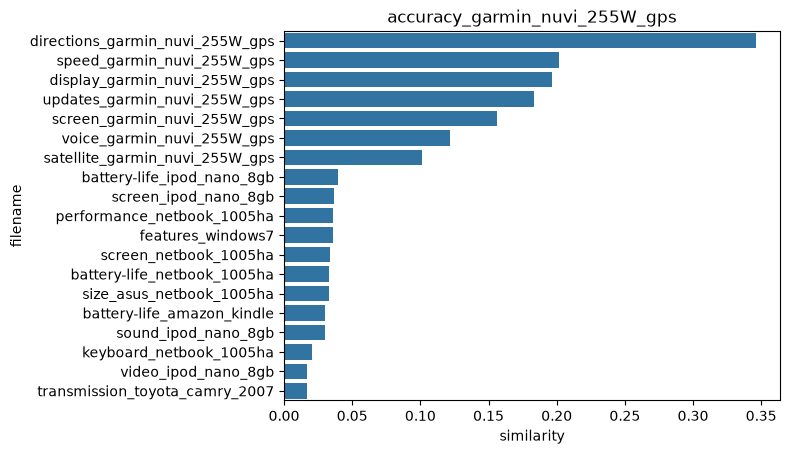

In [17]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


# argsort()를 이용하여 앞예제의 첫번째 문서와 타 문서간 유사도가 큰 순으로 정렬한 인덱스 반환하되 자기 자신은 제외.
sorted_index = similarity_pair.argsort()[:,::-1]
sorted_index = sorted_index[:, 1:]


# 유사도가 큰 순으로 hotel_indexes를 추출하여 재 정렬.
hotel_sorted_indexes = hotel_indexes[sorted_index.reshape(-1)]


# 유사도가 큰 순으로 유사도 값을 재정렬하되 자기 자신은 제외
hotel_1_sim_value = np.sort(similarity_pair.reshape(-1))[::-1]
hotel_1_sim_value = hotel_1_sim_value[1:]


# 유사도가 큰 순으로 정렬된 Index와 유사도값을 이용하여 파일명과 유사도값을 Seaborn 막대 그래프로 시각화
hotel_1_sim_df = pd.DataFrame()
hotel_1_sim_df['filename'] = document_df.iloc[hotel_sorted_indexes]['filename']
hotel_1_sim_df['similarity'] = hotel_1_sim_value


fig1 = plt.gcf()
sns.barplot(x='similarity', y='filename',data=hotel_1_sim_df)
plt.title(comparison_docname)
fig1.savefig('p553_hotel.tif', format='tif', dpi=300, bbox_inches='tight')
